# Solar + Battery Decision Simulator — Walkthrough

A guided tour of the `solarbess` simulator. We walk through each of the eight architectural modules
(slide 4 of the design deck), exercise them on a single delivery day, then run a paired-seed
multi-episode evaluation across all three policies (rule-based, Pyomo, perfect-foresight oracle)
and a CVaR sweep.

**Pipeline**

1. **Truth generator** → seal one day of synthetic ground truth (solar + all prices).
2. **Information Oracle** → the only legal channel from world to policy. No look-ahead.
3. **Asset model** → solar PV + battery dynamics (solar-only charging).
4. **Market interface** → DA gate + 3 intraday auctions, price-taking clearing.
5. **Policy** → three callbacks: DA, intraday, dispatch.
6. **Profit accountant** → per-period PnL decomposition.
7. **Reporting** → HTML reports.
8. **Evaluation harness** → paired-seed N-episode runner, paired Wilcoxon test, empirical CVaR.

All four policies share the same callback contract; the only difference is what's inside.


In [1]:
from __future__ import annotations
from datetime import date, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from solarbess.config import AppConfig
from solarbess.clock import Clock, DSTTransitionError
from solarbess.world.truth import TruthGenerator
from solarbess.world.oracle import DecisionTime, InformationOracle
from solarbess.forecast.scenarios import ForecastGenerator
from solarbess.asset.battery import AssetModel, AssetState
from solarbess.policy.rule_based import RuleBasedPolicy
from solarbess.policy.pyomo_policy import PyomoPolicy
from solarbess.policy.oracle_policy import OraclePolicy
from solarbess.simulator.episode import run_episode
from solarbess.eval.harness import run_paired_evaluation
from solarbess.optim.builder import build_deterministic_model
from solarbess.optim.solve import solve_highs
import pyomo.environ as pyo

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

cfg = AppConfig.from_yaml('configs/default.yaml')
print(f'Battery   : {cfg.battery.capacity_mwh} MWh / {cfg.battery.p_charge_max_mw} MW')
print(f'Solar peak: {cfg.world.l2_solar.peak_mw} MW @ lat {cfg.world.l2_solar.latitude_deg} N')
print(f'MTU       : {cfg.mtu_minutes} min ({cfg.mtus_per_day} per day)')
print(f'Auctions  : DA + intraday at t-{cfg.market.intraday_lead_times_h} h')
print(f'Scenarios : {cfg.forecast.n_scenarios_da} (DA) / {cfg.forecast.n_scenarios_id} (intraday)')

Battery   : 20.0 MWh / 5.0 MW
Solar peak: 50.0 MW @ lat 58.7 N
MTU       : 15 min (96 per day)
Auctions  : DA + intraday at t-[6, 3, 1] h
Scenarios : 50 (DA) / 30 (intraday)


## 1. Truth generator — sealed ground truth for one day

The five-layer world (PDF slide 5):
- **L1** weekly+annual seasonality template, 2-state Markov regime (calm/stressed).
- **L2** solar = clear-sky envelope × stochastic clearness (OU in logit space).
- **L3** day-ahead price = base + load term **− solar coupling** + heavy-tailed shock. This is the channel by which sunny days depress midday prices.
- **L4** intraday spread per auction round, AR(1), correlated with the sign of the DA shock.
- **L5** imbalance prices: sign-dependent markup around DA, correlated with aggregate solar anomaly.

We seal one day. The TruthPath is generated **before the clock starts** and never modified;
all policy callbacks see only what `InformationOracle.view(...)` returns at the relevant decision time.


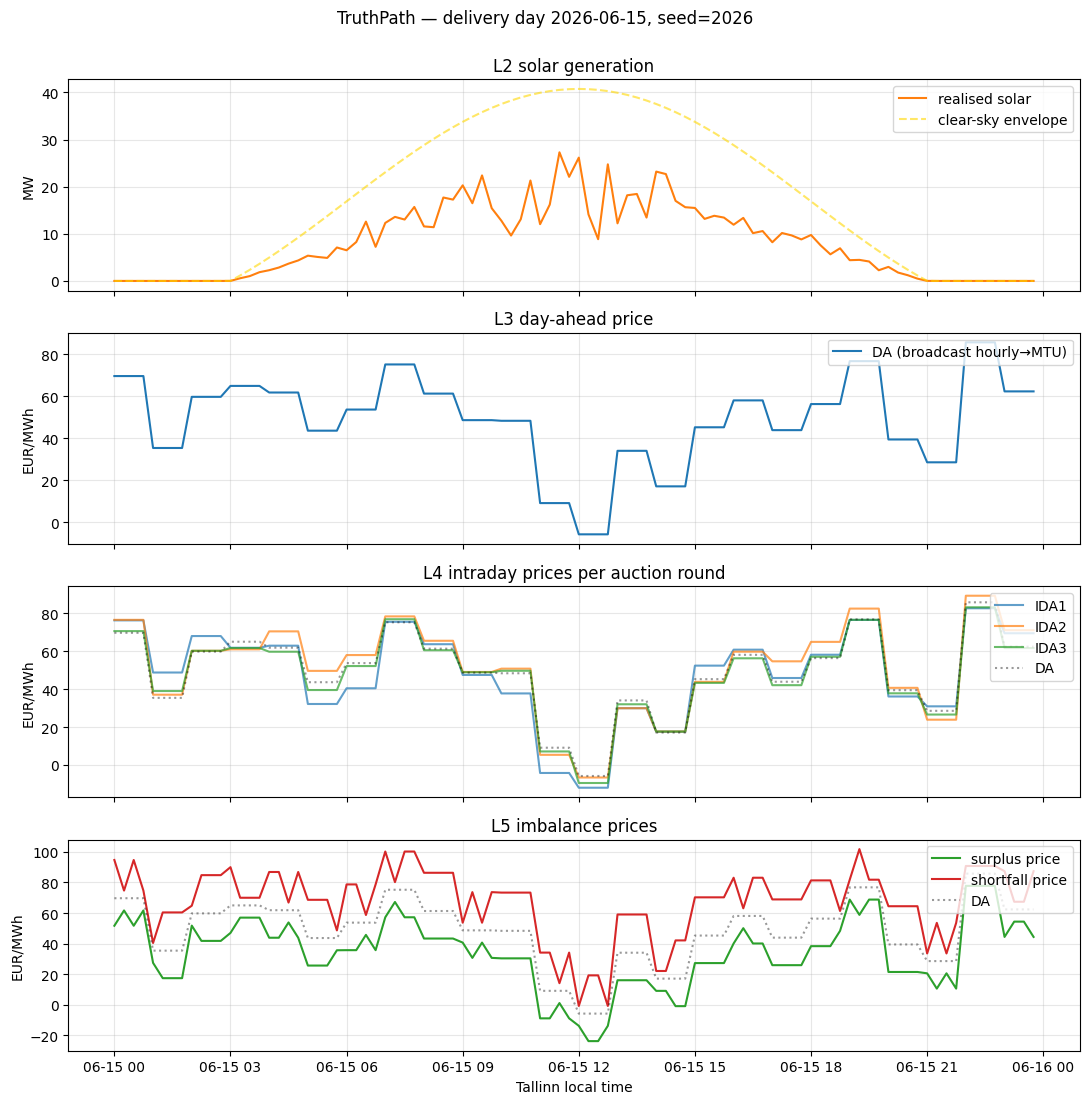

Day total solar production: 200.1 MWh
DA price range            : -5.8 ... 85.8 EUR/MWh


In [2]:
tg = TruthGenerator(cfg)
truth = tg.sample(date(2026, 6, 15), seed=2026)
local = truth.timestamps.tz_convert('Europe/Tallinn')

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

axes[0].plot(local, truth.solar_mw, color='tab:orange', label='realised solar')
axes[0].plot(local, truth.latent['envelope'] * cfg.world.l2_solar.peak_mw,
             color='gold', linestyle='--', alpha=0.6, label='clear-sky envelope')
axes[0].set_ylabel('MW'); axes[0].set_title('L2 solar generation'); axes[0].legend(loc='upper right')

axes[1].plot(local, truth.da_price_mtu, color='tab:blue', label='DA (broadcast hourly→MTU)')
axes[1].set_ylabel('EUR/MWh'); axes[1].set_title('L3 day-ahead price'); axes[1].legend(loc='upper right')

for r in range(truth.id_price_mtu.shape[1]):
    axes[2].plot(local, truth.id_price_mtu[:, r], alpha=0.7, label=f'IDA{r+1}')
axes[2].plot(local, truth.da_price_mtu, color='black', alpha=0.4, linestyle=':', label='DA')
axes[2].set_ylabel('EUR/MWh'); axes[2].set_title('L4 intraday prices per auction round'); axes[2].legend(loc='upper right')

axes[3].plot(local, truth.imb_surplus_price, color='tab:green', label='surplus price')
axes[3].plot(local, truth.imb_shortfall_price, color='tab:red', label='shortfall price')
axes[3].plot(local, truth.da_price_mtu, color='black', alpha=0.4, linestyle=':', label='DA')
axes[3].set_ylabel('EUR/MWh'); axes[3].set_title('L5 imbalance prices'); axes[3].legend(loc='upper right')
axes[3].set_xlabel('Tallinn local time')

fig.suptitle(f'TruthPath — delivery day {truth.delivery_date}, seed=2026', y=1.00)
fig.tight_layout()
plt.show()
print(f'Day total solar production: {truth.solar_mw.sum() * cfg.dt_hours:.1f} MWh')
print(f'DA price range            : {truth.da_price_mtu.min():.1f} ... {truth.da_price_mtu.max():.1f} EUR/MWh')

## 2. Latent layers — what's driving the day

The Markov regime, clearness OU and load shape are kept on `truth.latent` for diagnostics — the
**policy never sees these**, but they're invaluable for understanding why prices and solar look
the way they do.


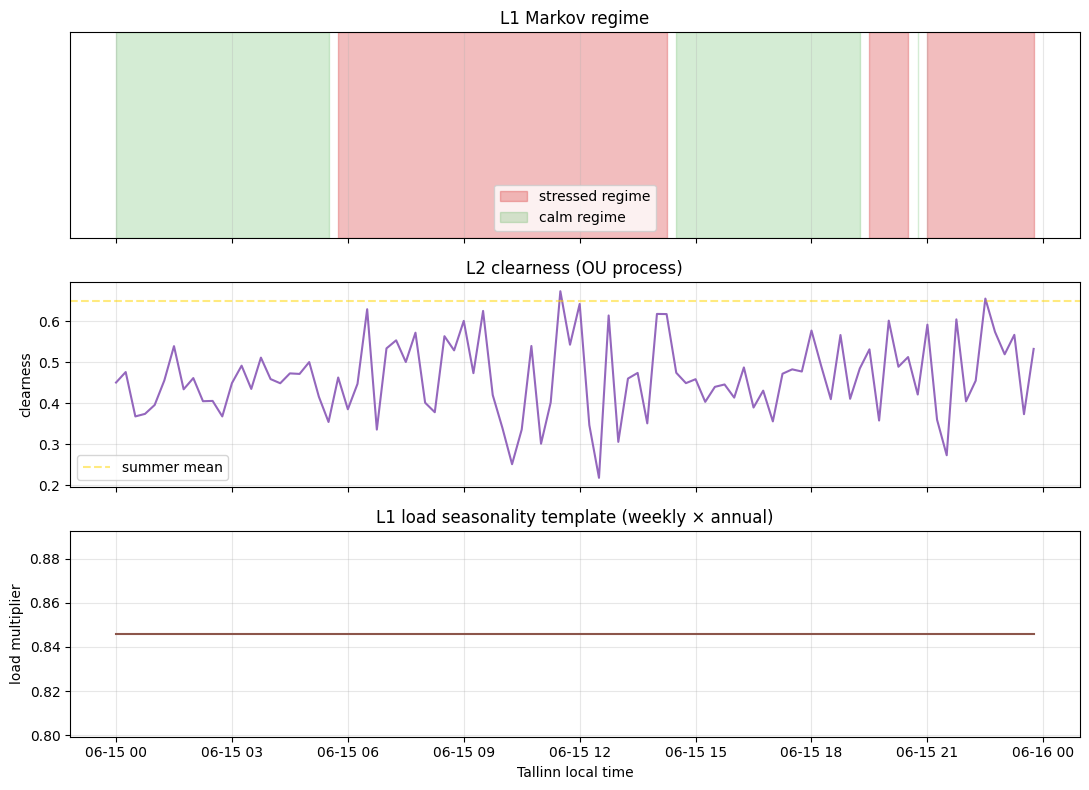

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].fill_between(local, 0, 1, where=truth.latent['regime'] == 1,
                     color='tab:red', alpha=0.3, label='stressed regime')
axes[0].fill_between(local, 0, 1, where=truth.latent['regime'] == 0,
                     color='tab:green', alpha=0.2, label='calm regime')
axes[0].set_ylim(0, 1); axes[0].set_title('L1 Markov regime'); axes[0].legend()
axes[0].set_yticks([])

axes[1].plot(local, truth.latent['clearness'], color='tab:purple')
axes[1].axhline(cfg.world.l2_solar.clearness_mean_summer, linestyle='--', color='gold', alpha=0.5,
                label='summer mean')
axes[1].set_ylabel('clearness'); axes[1].set_title('L2 clearness (OU process)'); axes[1].legend()

axes[2].plot(local, truth.latent['seasonality'], color='tab:brown')
axes[2].set_ylabel('load multiplier'); axes[2].set_title('L1 load seasonality template (weekly × annual)')
axes[2].set_xlabel('Tallinn local time')
fig.tight_layout()
plt.show()

## 3. World validation — does the solar/price coupling work?

The PDF (slide 5) warns: if L2 and L3 are simulated independently, sunny midday hours won't depress
prices and the optimiser will look artificially good. Let's check empirically that the channel
is active.


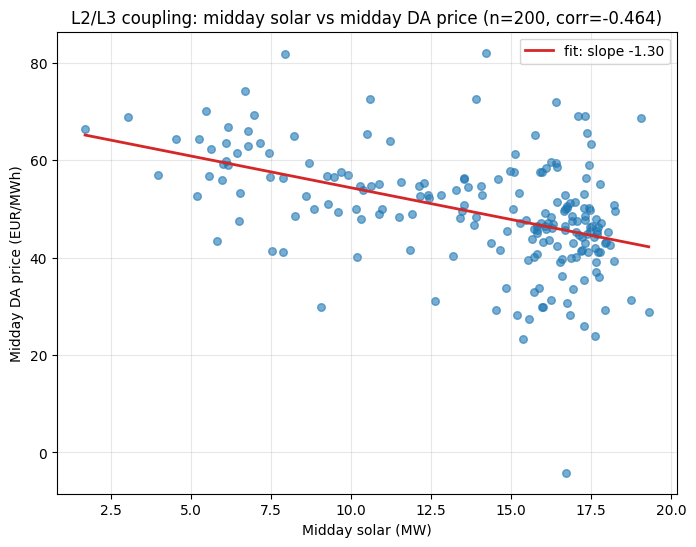

Pass threshold: corr < -0.20  →  observed -0.464  →  PASS


In [4]:
solars, prices = [], []
collected, k = 0, 0
while collected < 200 and k < 600:
    try:
        t = tg.sample(date(2026, 5, 1) + timedelta(days=k), seed=20_000 + k)
        # MTU 48 = local noon (start at local 00:00, +12 h = solar peak)
        solars.append(t.solar_mw[48:60].mean())
        prices.append(t.da_price_mtu[48:60].mean())
        collected += 1
    except DSTTransitionError:
        pass
    k += 1

solars = np.array(solars); prices = np.array(prices)
corr = float(np.corrcoef(solars, prices)[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(solars, prices, alpha=0.6, s=30)
ax.set_xlabel('Midday solar (MW)'); ax.set_ylabel('Midday DA price (EUR/MWh)')
ax.set_title(f'L2/L3 coupling: midday solar vs midday DA price (n={collected}, corr={corr:.3f})')
z = np.polyfit(solars, prices, 1); p = np.poly1d(z)
ax.plot(np.sort(solars), p(np.sort(solars)), color='tab:red', linewidth=2, label=f'fit: slope {z[0]:.2f}')
ax.legend()
plt.show()
print(f'Pass threshold: corr < -0.20  →  observed {corr:.3f}  →  {"PASS" if corr < -0.20 else "FAIL"}')

## 4. Asset model — battery SoC dynamics

A pure mechanical step:
```
soc[t+1] = soc[t] + η_ch · charge · dt − discharge · dt / η_dis
```
plus a hard guard `charge ≤ realised_solar` (solar-only charging — no grid imports). Below: a
12-step demo on a tiny synthetic solar profile.


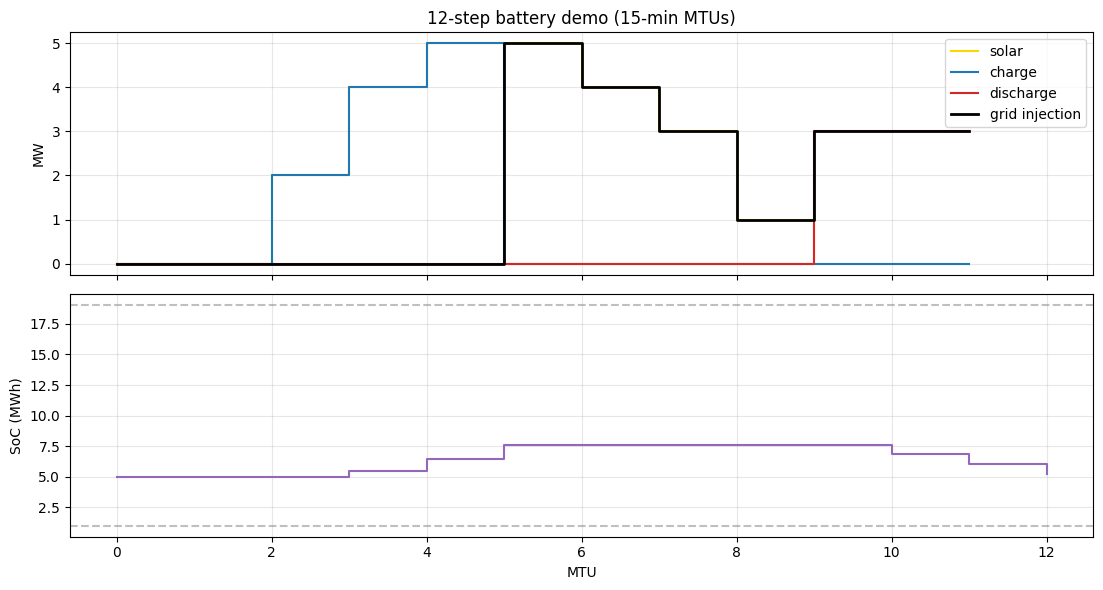

In [5]:
asset = AssetModel(cfg.battery, pv_peak_mw=cfg.world.l2_solar.peak_mw, inverter_limit_mw=55)
state = AssetState(soc_mwh=cfg.battery.soc_initial_mwh)
solar_profile = np.array([0, 0, 2, 4, 5, 5, 4, 3, 1, 0, 0, 0], dtype=float)
charge_plan   = np.array([0, 0, 2, 4, 5, 0, 0, 0, 0, 0, 0, 0], dtype=float)
discharge_plan= np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3], dtype=float)

socs = [state.soc_mwh]; injections = []
for i in range(12):
    state, inj = asset.step(state, charge_plan[i], discharge_plan[i], solar_profile[i], cfg.dt_hours)
    socs.append(state.soc_mwh); injections.append(inj)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].step(range(12), solar_profile, where='post', label='solar', color='gold')
axes[0].step(range(12), charge_plan,   where='post', label='charge', color='tab:blue')
axes[0].step(range(12), discharge_plan,where='post', label='discharge', color='tab:red')
axes[0].step(range(12), injections,    where='post', label='grid injection', color='black', linewidth=2)
axes[0].set_ylabel('MW'); axes[0].set_title('12-step battery demo (15-min MTUs)'); axes[0].legend()
axes[1].step(range(13), socs, where='post', color='tab:purple')
axes[1].axhline(cfg.battery.soc_min_mwh, linestyle='--', color='gray', alpha=0.5)
axes[1].axhline(cfg.battery.soc_max_mwh, linestyle='--', color='gray', alpha=0.5)
axes[1].set_ylabel('SoC (MWh)'); axes[1].set_xlabel('MTU')
fig.tight_layout()
plt.show()

## 5. Information Oracle — the firewall

The Oracle is the **only** legal channel from world to policy. At each decision time it returns an
`InfoSet` containing realised values up to `now` (the rest masked as NaN) plus a freshly-generated
`ScenarioForecast` over the remaining tradable horizon.

Below: solar values revealed at three decision points. Note how the NaN window shrinks as time
progresses.


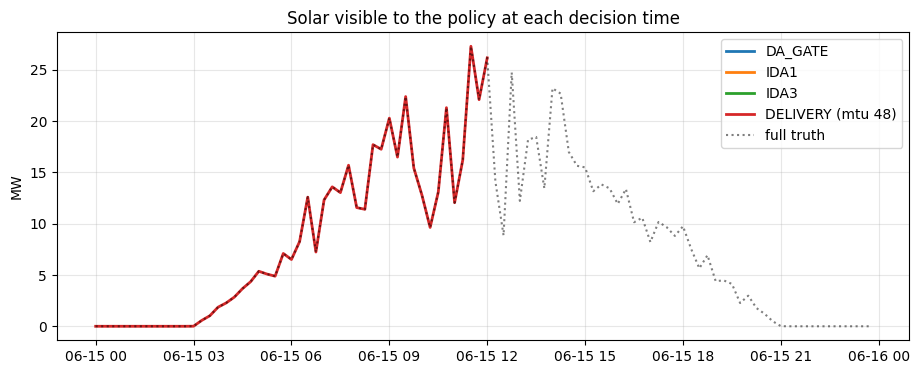

In [6]:
fg = ForecastGenerator(cfg.forecast)
oracle = InformationOracle(truth, fg)
clock = Clock(delivery_date=truth.delivery_date, mtu_minutes=cfg.mtu_minutes)

probe_times = {
    'DA_GATE':  clock.da_gate_utc(),
    'IDA1':     clock.mtu_index()[0] - pd.Timedelta(hours=6),
    'IDA3':     clock.mtu_index()[0] - pd.Timedelta(hours=1),
    'DELIVERY (mtu 48)': clock.mtu_index()[48] + pd.Timedelta(minutes=15),
}

fig, ax = plt.subplots(figsize=(11, 4))
for label, now in probe_times.items():
    info = oracle.view(
        DecisionTime[label.split()[0]] if 'DELIVERY' not in label else DecisionTime.DELIVERY,
        now=now,
        n_scenarios=20,
        forecast_seed=1,
        delivery_period_idx=48 if 'DELIVERY' in label else None,
    )
    revealed = ~np.isnan(info.realized_solar_so_far)
    ax.plot(local, np.where(revealed, info.realized_solar_so_far, np.nan), label=label, linewidth=2)
ax.plot(local, truth.solar_mw, color='black', linestyle=':', alpha=0.5, label='full truth')
ax.set_ylabel('MW'); ax.set_title('Solar visible to the policy at each decision time'); ax.legend()
plt.show()

## 6. Forecast generator — scenarios = truth + structured error

`forecast = truth + lead-time-scaled, temporally-correlated, cross-correlated error`.

Three properties:
- Variance scales with lead time: σ(Δt) = σ_floor + (σ_max − σ_floor)(1 − e^(−Δt/τ_lead))
- Temporal correlation: ρ_ij = e^(−|t_i − t_j|/τ_corr) (Matern-1/2)
- Solar–DA cross correlation imposed by mixing the two error streams.

Below: a fan plot of solar scenarios at the DA gate vs. truth.


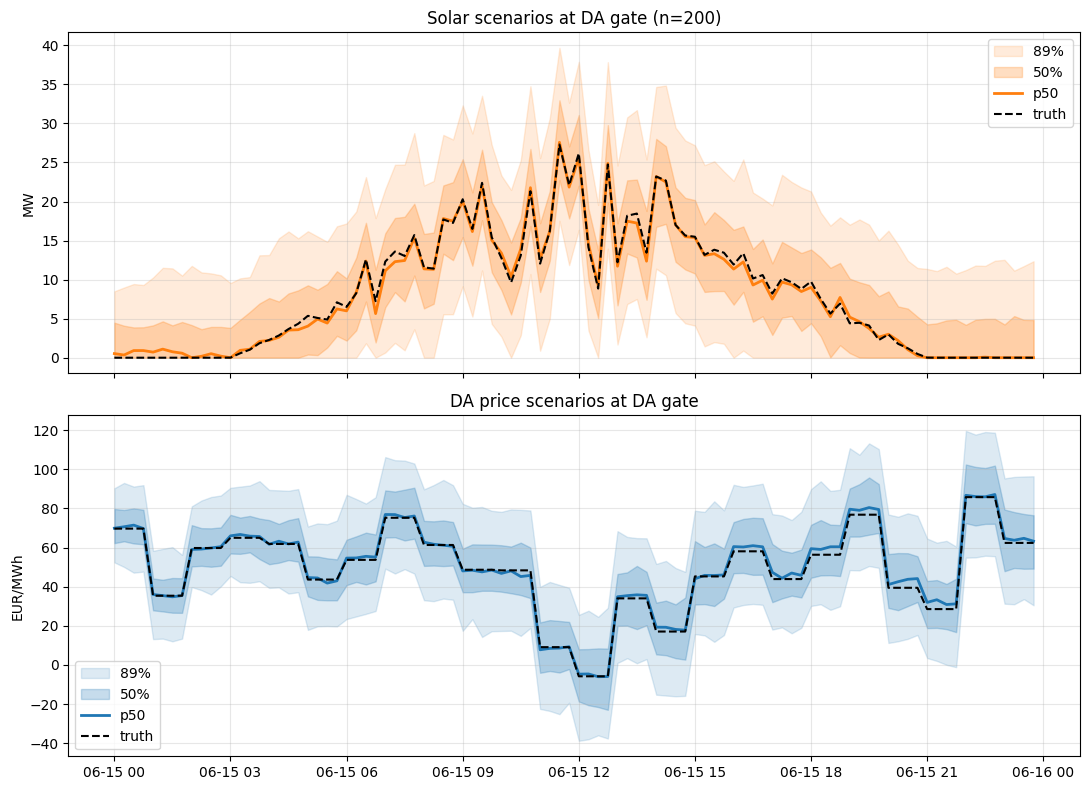

Probability sum: 1.0000000000
Mean error vs truth (solar): +1.043 MW


In [7]:
sc = fg.generate(truth, now=clock.da_gate_utc(),
                 decision_time=DecisionTime.DA_GATE, n_scenarios=200, seed=42)
ts_local = sc.timestamps.tz_convert('Europe/Tallinn')

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for q_low, q_high, alpha in [(0.05, 0.95, 0.15), (0.25, 0.75, 0.25)]:
    axes[0].fill_between(ts_local, np.quantile(sc.solar_mw, q_low, axis=0),
                         np.quantile(sc.solar_mw, q_high, axis=0),
                         alpha=alpha, color='tab:orange', label=f'{int((q_high-q_low)*100)}%')
axes[0].plot(ts_local, np.median(sc.solar_mw, axis=0), color='tab:orange', linewidth=2, label='p50')
axes[0].plot(ts_local, truth.solar_mw, color='black', linestyle='--', label='truth')
axes[0].set_ylabel('MW'); axes[0].set_title('Solar scenarios at DA gate (n=200)'); axes[0].legend()

for q_low, q_high, alpha in [(0.05, 0.95, 0.15), (0.25, 0.75, 0.25)]:
    axes[1].fill_between(ts_local, np.quantile(sc.da_price, q_low, axis=0),
                         np.quantile(sc.da_price, q_high, axis=0),
                         alpha=alpha, color='tab:blue', label=f'{int((q_high-q_low)*100)}%')
axes[1].plot(ts_local, np.median(sc.da_price, axis=0), color='tab:blue', linewidth=2, label='p50')
axes[1].plot(ts_local, truth.da_price_mtu, color='black', linestyle='--', label='truth')
axes[1].set_ylabel('EUR/MWh'); axes[1].set_title('DA price scenarios at DA gate'); axes[1].legend()
fig.tight_layout()
plt.show()
print(f'Probability sum: {sc.probabilities.sum():.10f}')
print(f'Mean error vs truth (solar): {(sc.solar_mw.mean(axis=0) - truth.solar_mw).mean():+.3f} MW')

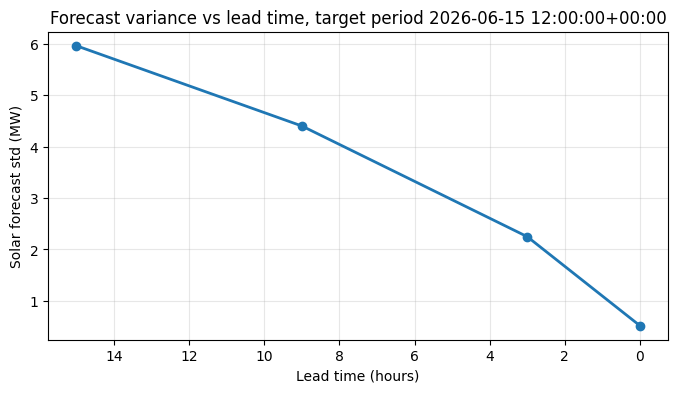

In [8]:
# Variance shrinks as the decision time approaches delivery.
target_idx = 60                                  # late afternoon delivery period
target_t   = truth.timestamps[target_idx]
sigmas, leads = [], []
for hours_before_start in [24, 18, 12, 9, 6, 3, 1]:
    now = truth.timestamps[0] - pd.Timedelta(hours=hours_before_start - 24)
    if now > target_t: continue
    sc_t = fg.generate(truth, now=now, decision_time=DecisionTime.IDA1, n_scenarios=300, seed=11)
    j = pd.Index(sc_t.timestamps).get_loc(target_t)
    sigmas.append(float(np.std(sc_t.solar_mw[:, j])))
    leads.append((target_t - now) / pd.Timedelta(hours=1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(leads, sigmas, marker='o', linewidth=2)
ax.set_xlabel('Lead time (hours)'); ax.set_ylabel('Solar forecast std (MW)')
ax.set_title(f'Forecast variance vs lead time, target period {target_t}')
ax.invert_xaxis()
plt.show()

## 7. Pyomo optimisation — deterministic LP on truth

Build the deterministic Pyomo model on the truth path (= what the OraclePolicy does) and inspect
the optimal decision variables. The variable list mirrors the math in `plan.md` §8:
`q_da, q_id, charge, discharge, soc, curtail, imb_pos, imb_neg`.


Termination: TerminationCondition.optimal
Objective  : 9053.22 EUR (oracle upper bound)


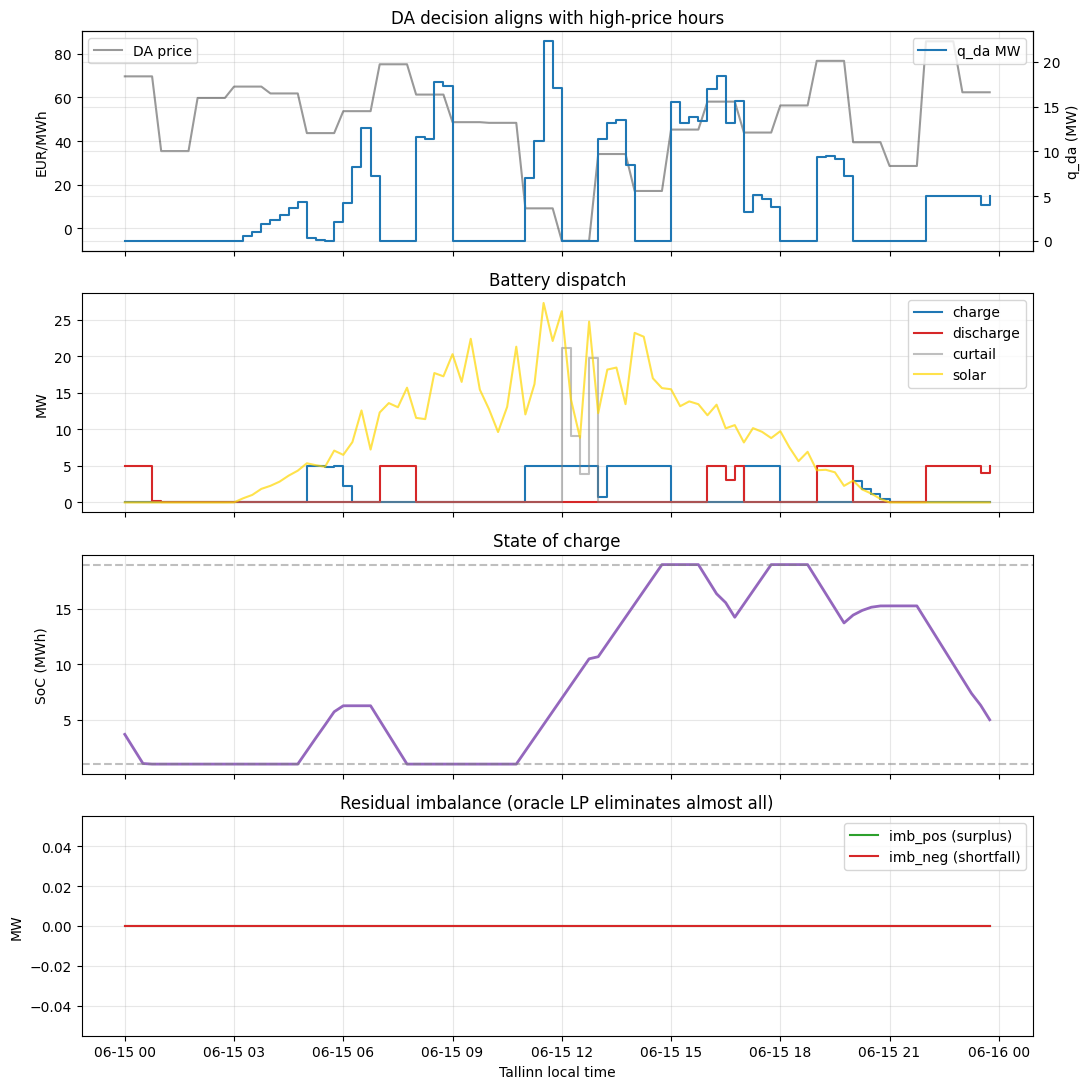

In [9]:
m = build_deterministic_model(
    times=truth.timestamps,
    solar_mw=truth.solar_mw,
    da_price_mtu=truth.da_price_mtu,
    id_price_mtu=truth.id_price_mtu[:, -1],
    imb_surplus=truth.imb_surplus_price,
    imb_shortfall=truth.imb_shortfall_price,
    battery=cfg.battery, market=cfg.market,
    dt_hours=cfg.dt_hours, soc_initial_mwh=cfg.battery.soc_initial_mwh,
)
res = solve_highs(m, time_limit_s=10.0)
print(f'Termination: {res.termination}')
print(f'Objective  : {res.objective:.2f} EUR (oracle upper bound)')

q_da   = np.array([pyo.value(m.q_da[t])    for t in m.T])
charge = np.array([pyo.value(m.charge[t])  for t in m.T])
discharge = np.array([pyo.value(m.discharge[t]) for t in m.T])
soc    = np.array([pyo.value(m.soc[t])     for t in m.T])
curtail= np.array([pyo.value(m.curtail[t]) for t in m.T])
imb_pos= np.array([pyo.value(m.imb_pos[t]) for t in m.T])
imb_neg= np.array([pyo.value(m.imb_neg[t]) for t in m.T])

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
axes[0].plot(local, truth.da_price_mtu, color='black', alpha=0.4, label='DA price')
ax2 = axes[0].twinx()
ax2.step(local, q_da, where='post', color='tab:blue', label='q_da MW')
axes[0].set_ylabel('EUR/MWh'); ax2.set_ylabel('q_da (MW)')
axes[0].set_title('DA decision aligns with high-price hours')
axes[0].legend(loc='upper left'); ax2.legend(loc='upper right')

axes[1].step(local, charge,    where='post', color='tab:blue', label='charge')
axes[1].step(local, discharge, where='post', color='tab:red', label='discharge')
axes[1].step(local, curtail,   where='post', color='gray', alpha=0.5, label='curtail')
axes[1].plot(local, truth.solar_mw, color='gold', alpha=0.7, label='solar')
axes[1].set_ylabel('MW'); axes[1].set_title('Battery dispatch'); axes[1].legend()

axes[2].plot(local, soc, color='tab:purple', linewidth=2)
axes[2].axhline(cfg.battery.soc_min_mwh, linestyle='--', color='gray', alpha=0.5)
axes[2].axhline(cfg.battery.soc_max_mwh, linestyle='--', color='gray', alpha=0.5)
axes[2].set_ylabel('SoC (MWh)'); axes[2].set_title('State of charge')

axes[3].plot(local, imb_pos, color='tab:green', label='imb_pos (surplus)')
axes[3].plot(local, imb_neg, color='tab:red',   label='imb_neg (shortfall)')
axes[3].set_ylabel('MW'); axes[3].set_xlabel('Tallinn local time')
axes[3].set_title('Residual imbalance (oracle LP eliminates almost all)'); axes[3].legend()
fig.tight_layout()
plt.show()

## 8. Side-by-side: all four policies on the same day

Same `TruthPath`, same forecast noise seed → only the policy logic varies. The OraclePolicy reads
the truth path directly (perfect foresight upper bound); every other policy consumes only `InfoSet`.


In [10]:
policies = {
    'rule_based':           RuleBasedPolicy(cfg.battery, cfg.market, cfg.dt_hours),
    'pyomo_deterministic':  PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours, use_stochastic=False),
    'pyomo_stochastic':     PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours, use_stochastic=True),
    'oracle':               OraclePolicy(cfg.battery, cfg.market, cfg.dt_hours, truth),
}
results = {name: run_episode(truth, cfg, pol, fg, forecast_seed=999) for name, pol in policies.items()}

rows = []
for name, r in results.items():
    p = r.pnl
    rows.append([name, p.total, p.da_revenue, p.id_revenue, p.imbalance_revenue,
                 p.degradation_cost, p.fees, r.final_soc_mwh, r.cumulative_throughput_mwh])
pnl_df = pd.DataFrame(rows, columns=['policy', 'total', 'da', 'id', 'imb', 'degr', 'fees',
                                     'final_soc', 'throughput'])
pnl_df

,policy,total,da,id,imb,degr,fees,final_soc,throughput
0,rule_based,8158.299781,8832.440042,-1048.872111,540.480869,151.962331,13.786689,5.944869,37.990583
1,pyomo_deterministic,8404.572397,8905.781917,1121.140641,-1389.599658,220.389903,12.360599,1.000000,55.097476
2,pyomo_stochastic,8497.774617,3773.587537,5337.676161,-353.918994,245.457386,14.112703,1.000000,61.364346
3,oracle,8825.836271,5287.092048,4002.834466,-218.198589,236.711232,9.180423,5.000000,59.177808


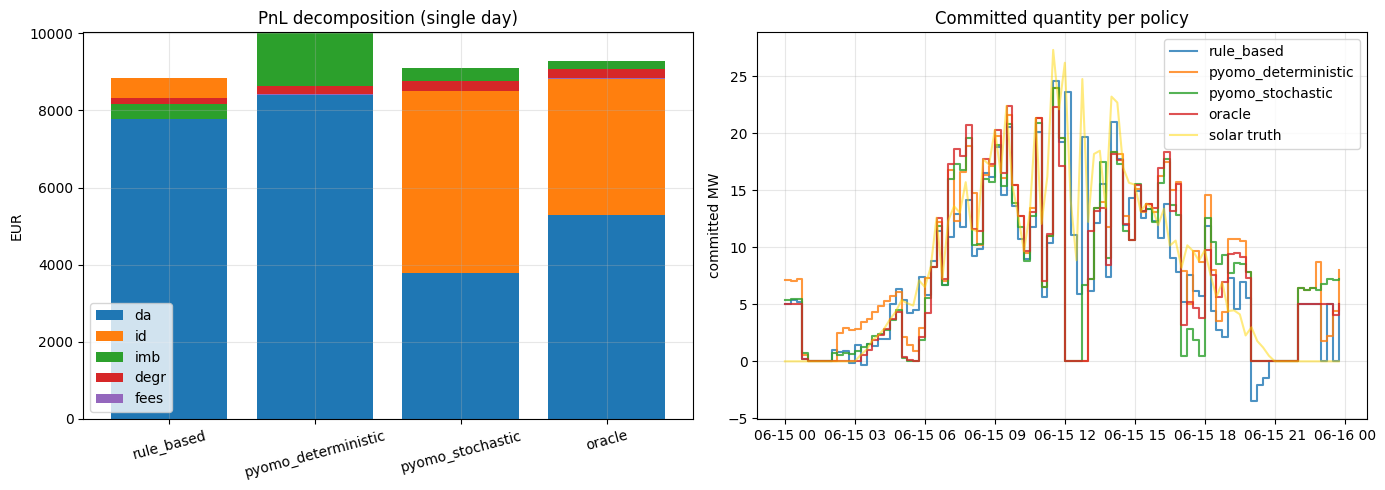

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
components = ['da', 'id', 'imb', 'degr', 'fees']
bottoms = np.zeros(len(policies))
for c in components:
    vals = pnl_df[c].values * (1 if c not in ('degr', 'fees') else -1)
    axes[0].bar(pnl_df['policy'], vals, bottom=bottoms, label=c)
    bottoms += vals
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('EUR'); axes[0].set_title('PnL decomposition (single day)')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=15)

for name, r in results.items():
    axes[1].step(local, r.timeseries['committed_mw'], where='post', label=name, alpha=0.8)
axes[1].plot(local, truth.solar_mw, color='gold', alpha=0.5, label='solar truth')
axes[1].set_ylabel('committed MW'); axes[1].set_title('Committed quantity per policy')
axes[1].legend()
fig.tight_layout()
plt.show()

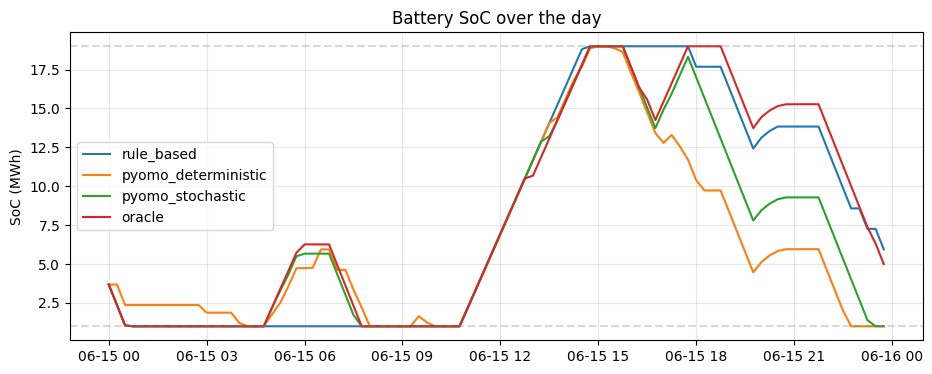

In [12]:
# SoC trajectories - how aggressively does each policy cycle the battery?
fig, ax = plt.subplots(figsize=(11, 4))
for name, r in results.items():
    ax.plot(local, r.timeseries['soc_mwh'], label=name)
ax.axhline(cfg.battery.soc_min_mwh, linestyle='--', color='gray', alpha=0.3)
ax.axhline(cfg.battery.soc_max_mwh, linestyle='--', color='gray', alpha=0.3)
ax.set_ylabel('SoC (MWh)'); ax.set_title('Battery SoC over the day'); ax.legend()
plt.show()

## 9. Multi-episode paired evaluation

Same world seed across policies per episode → all policies face the same truth (variance reduction).
Then we compute the paired Wilcoxon test on per-episode profit differences.


In [13]:
factories = {
    'rule_based':           lambda _t: RuleBasedPolicy(cfg.battery, cfg.market, cfg.dt_hours),
    'pyomo_deterministic':  lambda _t: PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours, use_stochastic=False),
    'pyomo_stochastic':     lambda _t: PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours, use_stochastic=True),
    'oracle':               lambda t:  OraclePolicy(cfg.battery, cfg.market, cfg.dt_hours, t),
}
report = run_paired_evaluation(
    policy_factories=factories,
    cfg=cfg,
    n_episodes=15,
    base_seed=909,
    start_date=date(2026, 6, 1),
    cvar_alpha=cfg.cvar.alpha,
)
print(report.summary_table().to_string(index=False))

             policy  n_episodes  mean_profit_eur  median_profit_eur  std_profit_eur  cvar_95_loss_eur
         rule_based          15      8559.470718        8714.635030     2155.709109      -1786.921438
pyomo_deterministic          15      8665.953474        9036.618905     2230.755597      -1486.074961
   pyomo_stochastic          15      8694.459010        9254.920253     2212.134367      -1712.712001
             oracle          15      9101.995406        9248.157014     2201.375326      -2003.552682


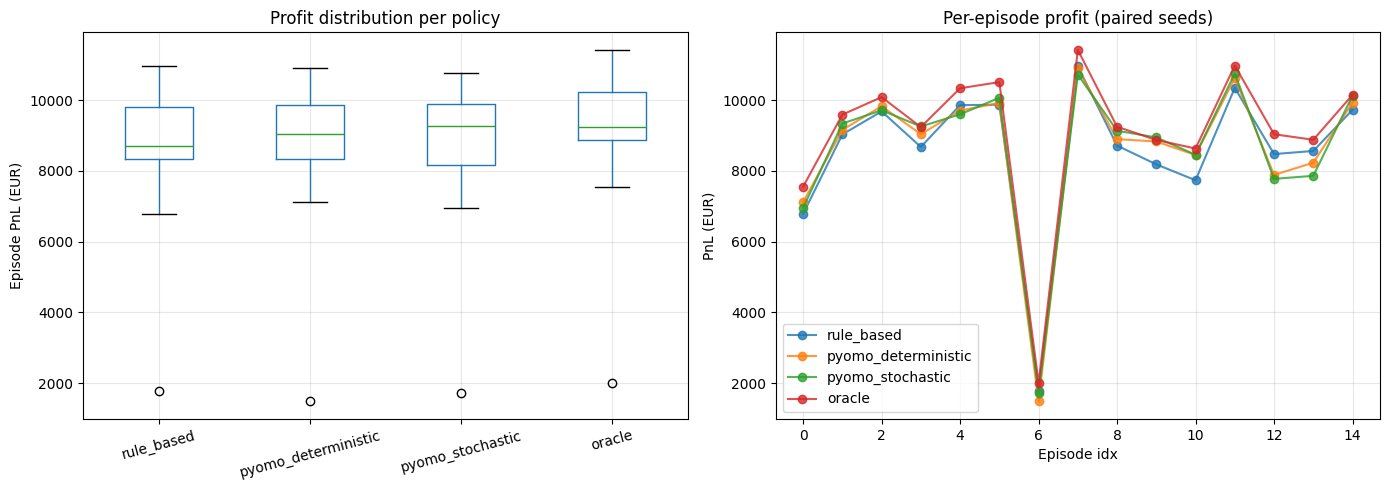

In [14]:
# Per-episode profit table + boxplot
profit_df = pd.DataFrame({name: report.profit_array(name) for name in factories})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
profit_df.boxplot(ax=axes[0])
axes[0].set_ylabel('Episode PnL (EUR)'); axes[0].set_title('Profit distribution per policy')
axes[0].tick_params(axis='x', rotation=15)

for col in profit_df.columns:
    axes[1].plot(profit_df.index, profit_df[col], marker='o', label=col, alpha=0.8)
axes[1].set_xlabel('Episode idx'); axes[1].set_ylabel('PnL (EUR)')
axes[1].set_title('Per-episode profit (paired seeds)')
axes[1].legend()
fig.tight_layout()
plt.show()

In [15]:
# Significance tests (paired Wilcoxon and paired t)
rows = []
for c in report.comparisons:
    rows.append([c.label_a, c.label_b, c.mean_diff, c.median_diff,
                 c.paired_t_pvalue, c.wilcoxon_pvalue])
sig_df = pd.DataFrame(rows, columns=['a', 'b', 'mean(a-b)', 'median(a-b)', 't p', 'Wilcoxon p'])
sig_df

,a,b,mean(a-b),median(a-b),t p,Wilcoxon p
0,rule_based,pyomo_deterministic,-106.482756,-144.994940,2.641194e-01,0.276855
1,rule_based,pyomo_stochastic,-134.988292,-196.242058,2.730238e-01,0.229309
2,rule_based,oracle,-542.524688,-559.786507,7.793145e-09,0.000061
3,pyomo_deterministic,pyomo_stochastic,-28.505536,-114.314917,5.666346e-01,0.302795
4,pyomo_deterministic,oracle,-436.041932,-432.096129,1.874151e-05,0.000061
5,pyomo_stochastic,oracle,-407.536396,-290.840681,1.150930e-03,0.000427


## 10. CVaR sweep — Phase 3 risk-vs-return tradeoff

The CVaR layer (`optim/cvar.py`) adds:
- variables `z_cvar` and `u_cvar[ω] ≥ 0`
- constraint `u_cvar[ω] ≥ −profit[ω] − z_cvar`
- objective term `− λ_cvar · (z_cvar + (1/(1−α)) · Σ p[ω]·u_cvar[ω])`

Increasing λ_cvar should reduce tail loss while reducing expected profit. We sweep three values
on a smaller episode count (each Pyomo solve is non-trivial).


In [16]:
cvar_factories = {
    'lambda=0.0': lambda _t: PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours,
                                          use_stochastic=True, lambda_cvar=0.0, name='lambda=0.0'),
    'lambda=0.5': lambda _t: PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours,
                                          use_stochastic=True, lambda_cvar=0.5, cvar_alpha=0.9,
                                          name='lambda=0.5'),
    'lambda=1.5': lambda _t: PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours,
                                          use_stochastic=True, lambda_cvar=1.5, cvar_alpha=0.9,
                                          name='lambda=1.5'),
}
cvar_report = run_paired_evaluation(
    policy_factories=cvar_factories,
    cfg=cfg,
    n_episodes=10,
    base_seed=4242,
    start_date=date(2026, 6, 1),
    cvar_alpha=0.9,
)
cvar_summary = cvar_report.summary_table()
cvar_summary

,policy,n_episodes,mean_profit_eur,median_profit_eur,std_profit_eur,cvar_90_loss_eur
0,lambda=0.0,10,8730.717059,9487.836410,1858.500403,-5028.550018
1,lambda=0.5,10,8715.862032,9435.265227,1812.139083,-5111.088747
2,lambda=1.5,10,8708.235434,9408.003813,1783.007621,-5154.646355


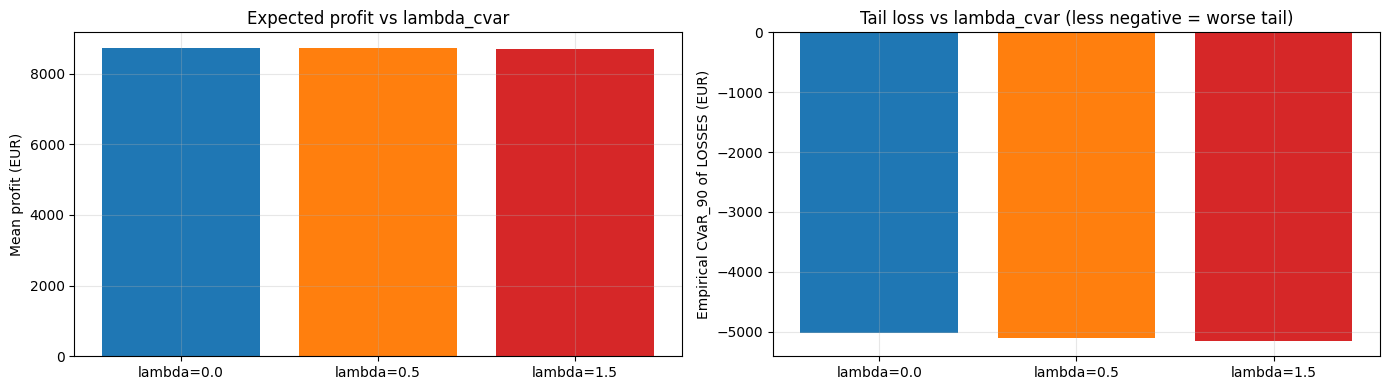

In [17]:
# Visualise the risk/return tradeoff
means = cvar_summary['mean_profit_eur'].values
cvars = cvar_summary['cvar_90_loss_eur'].values
names = cvar_summary['policy'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(names, means, color=['tab:blue', 'tab:orange', 'tab:red'])
axes[0].set_ylabel('Mean profit (EUR)'); axes[0].set_title('Expected profit vs lambda_cvar')

axes[1].bar(names, cvars, color=['tab:blue', 'tab:orange', 'tab:red'])
axes[1].set_ylabel('Empirical CVaR_90 of LOSSES (EUR)')
axes[1].set_title('Tail loss vs lambda_cvar (less negative = worse tail)')
fig.tight_layout()
plt.show()

## 11. Phase 4 — MILP no-simultaneous charge/discharge

A pure LP allows the optimiser to open both charge and discharge in the same MTU. Under our
default config (`degradation_cost = 4 EUR/MWh`) this is implicitly penalised, so it rarely
happens, but it CAN happen under unusual price patterns. Phase 4 adds a binary
`y_charge[t] ∈ {0,1}` that forbids it structurally:

```
charge[t]    ≤ P_charge_max    · y_charge[t]
discharge[t] ≤ P_discharge_max · (1 − y_charge[t])
```

The cost is computational: HiGHS now has to solve a MILP with `96 · n_scenarios` binary vars.


In [18]:
from solarbess.optim.helpers import add_no_simultaneous_charge_discharge  # noqa
# Side-by-side: same day, deterministic LP vs MILP
lp_policy   = PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours,
                           use_stochastic=False, binary_battery_mode=False)
milp_policy = PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours,
                           use_stochastic=False, binary_battery_mode=True)
r_lp   = run_episode(truth, cfg, lp_policy,   fg, forecast_seed=42)
r_milp = run_episode(truth, cfg, milp_policy, fg, forecast_seed=42)

both_lp   = ((r_lp.timeseries.charge_mw   > 1e-6) & (r_lp.timeseries.discharge_mw   > 1e-6)).sum()
both_milp = ((r_milp.timeseries.charge_mw > 1e-6) & (r_milp.timeseries.discharge_mw > 1e-6)).sum()
print(f'Periods with BOTH legs open  - LP: {both_lp:3d}  MILP: {both_milp:3d}  (MILP must be 0)')
print(f'Total PnL                    - LP: {r_lp.pnl.total:.2f}   MILP: {r_milp.pnl.total:.2f}')
print(f'Battery throughput (MWh)     - LP: {r_lp.cumulative_throughput_mwh:.2f}    MILP: {r_milp.cumulative_throughput_mwh:.2f}')

Periods with BOTH legs open  - LP:   0  MILP:   0  (MILP must be 0)
Total PnL                    - LP: 8364.16   MILP: 8372.56
Battery throughput (MWh)     - LP: 55.81    MILP: 54.69


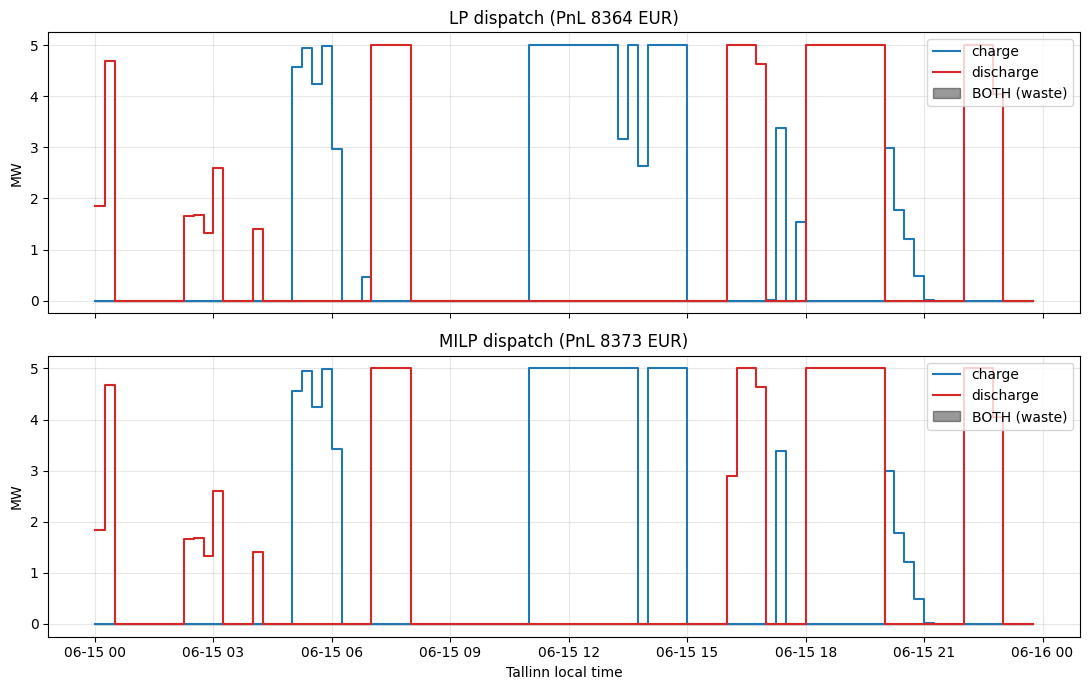

In [19]:
# Visualise: where (if anywhere) does the LP cycle simultaneously?
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, r, label in [(axes[0], r_lp, 'LP'), (axes[1], r_milp, 'MILP')]:
    ax.step(local, r.timeseries.charge_mw,    where='post', color='tab:blue', label='charge')
    ax.step(local, r.timeseries.discharge_mw, where='post', color='tab:red',  label='discharge')
    ax.fill_between(local, 0, np.minimum(r.timeseries.charge_mw, r.timeseries.discharge_mw),
                    color='black', alpha=0.4, label='BOTH (waste)')
    ax.set_title(f'{label} dispatch (PnL {r.pnl.total:.0f} EUR)')
    ax.set_ylabel('MW'); ax.legend(loc='upper right')
axes[1].set_xlabel('Tallinn local time')
fig.tight_layout()
plt.show()

## 12. Phase 5 — Rolling MPC at dispatch

The MPC variant re-solves a tail problem at each dispatch step:

- `mpc_dispatch_horizon = -1` → look ahead to end-of-day every solve.
- `mpc_dispatch_period = K` → re-solve every K MTUs (1 = every step).
- At each re-solve: fresh forecast at the current `now`, fixed `q_da` from the DA gate,
  current battery SoC, returns the dispatch decision for the *first* tail period.

Behaviour: dispatch decisions track the latest forecast rather than the stale plan baked at the
DA gate. With our synthetic zero-mean error model the gain is modest; the real value would come
from biased / drifting forecasts where re-solving lets the optimiser correct course.


In [20]:
# Compare cached-plan dispatch vs rolling MPC every 4 MTUs vs every 1 MTU
mpc_policies = {
    'no_mpc'        : PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours, use_stochastic=True),
    'mpc_full_p4'   : PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours, use_stochastic=True,
                                   mpc_dispatch_horizon=-1, mpc_dispatch_period=4,
                                   forecast_gen=fg, forecast_seed=99),
    'mpc_full_p1'   : PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours, use_stochastic=True,
                                   mpc_dispatch_horizon=-1, mpc_dispatch_period=1,
                                   forecast_gen=fg, forecast_seed=99),
}
mpc_results = {n: run_episode(truth, cfg, p, fg, forecast_seed=99) for n, p in mpc_policies.items()}
print(f'{"policy":<14}  {"PnL":>10}  {"throughput":>10}  {"dispatch resolves":>20}')
for n, r in mpc_results.items():
    n_solves = sum(1 for ch in r.timeseries.charge_mw if ch is not None)  # always 96
    print(f'{n:<14}  {r.pnl.total:>10.2f}  {r.cumulative_throughput_mwh:>10.2f}  {n_solves:>20}')

policy                 PnL  throughput     dispatch resolves
no_mpc             8340.47       53.15                    96
mpc_full_p4        8265.95       56.11                    96
mpc_full_p1        7780.32       61.21                    96


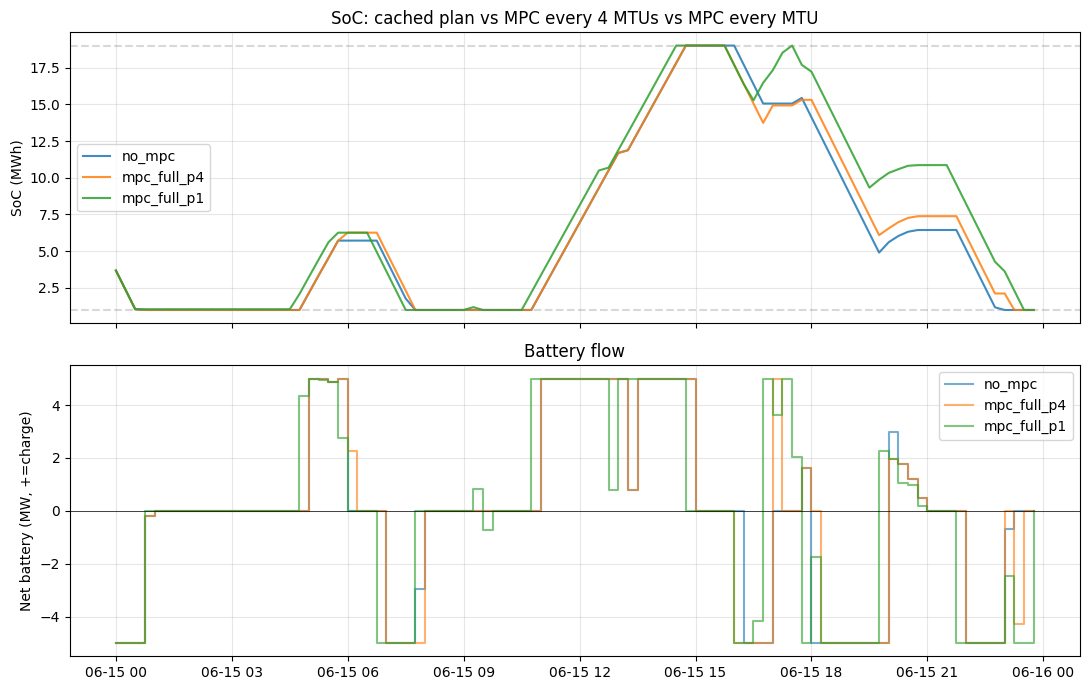

In [21]:
# How do the three SoC trajectories differ?
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for n, r in mpc_results.items():
    axes[0].plot(local, r.timeseries.soc_mwh, label=n, alpha=0.85)
    axes[1].step(local, r.timeseries.charge_mw - r.timeseries.discharge_mw,
                 where='post', label=n, alpha=0.6)
axes[0].axhline(cfg.battery.soc_min_mwh, ls='--', color='gray', alpha=0.3)
axes[0].axhline(cfg.battery.soc_max_mwh, ls='--', color='gray', alpha=0.3)
axes[0].set_ylabel('SoC (MWh)'); axes[0].set_title('SoC: cached plan vs MPC every 4 MTUs vs MPC every MTU')
axes[0].legend()
axes[1].set_ylabel('Net battery (MW, +=charge)'); axes[1].set_title('Battery flow')
axes[1].axhline(0, color='black', linewidth=0.5); axes[1].legend()
fig.tight_layout()
plt.show()

## 13. Phase 6 — Multi-stage scenario tree (non-anticipativity)

The two-stage stochastic LP has `q_id[ω, t]` — a separate intraday decision per scenario.
That implicitly lets the optimiser *peek* at the realisation when choosing q_id. The
**scenario tree** model corrects this: scenarios are grouped into IDA branches by a stage-1
feature (here: mean DA price in the first half of the day), and `q_id` is indexed by the
IDA *branch*, not the leaf. All leaves descending from the same IDA node must share `q_id` —
proper non-anticipativity.

Cost: the in-sample objective is **lower** (the tree gives up the implicit peek). Benefit:
out-of-sample decisions are realistic — the tree is what a real trader could implement.


In [22]:
from solarbess.forecast.tree import build_tree_from_scenarios
from solarbess.policy.tree_policy import TreePolicy

# Build a tree from a real forecast at the DA gate
sc_da = fg.generate(truth, now=clock.da_gate_utc(),
                    decision_time=DecisionTime.DA_GATE, n_scenarios=30, seed=77)
tree = build_tree_from_scenarios(sc_da, n_ida_nodes=4)
print(f'Tree: {len(tree.leaf_ids)} leaves, {len(tree.ida_node_ids)} IDA branches')
print(f'  leaf -> IDA assignments (sorted by mean DA price in first half-day):')
for k in tree.ida_node_ids:
    members = np.where(tree.leaf_to_ida == k)[0]
    feat = sc_da.da_price[members, :48].mean(axis=1)
    print(f'    IDA {k}: {len(members):2d} leaves, prob {tree.ida_probabilities[k]:.3f}, '
          f'DA-price-first-half range {feat.min():.1f}..{feat.max():.1f} EUR/MWh')

Tree: 30 leaves, 4 IDA branches
  leaf -> IDA assignments (sorted by mean DA price in first half-day):
    IDA 0:  8 leaves, prob 0.267, DA-price-first-half range 33.8..43.4 EUR/MWh
    IDA 1:  8 leaves, prob 0.267, DA-price-first-half range 43.9..53.7 EUR/MWh
    IDA 2:  7 leaves, prob 0.233, DA-price-first-half range 55.2..62.3 EUR/MWh
    IDA 3:  7 leaves, prob 0.233, DA-price-first-half range 62.9..71.4 EUR/MWh


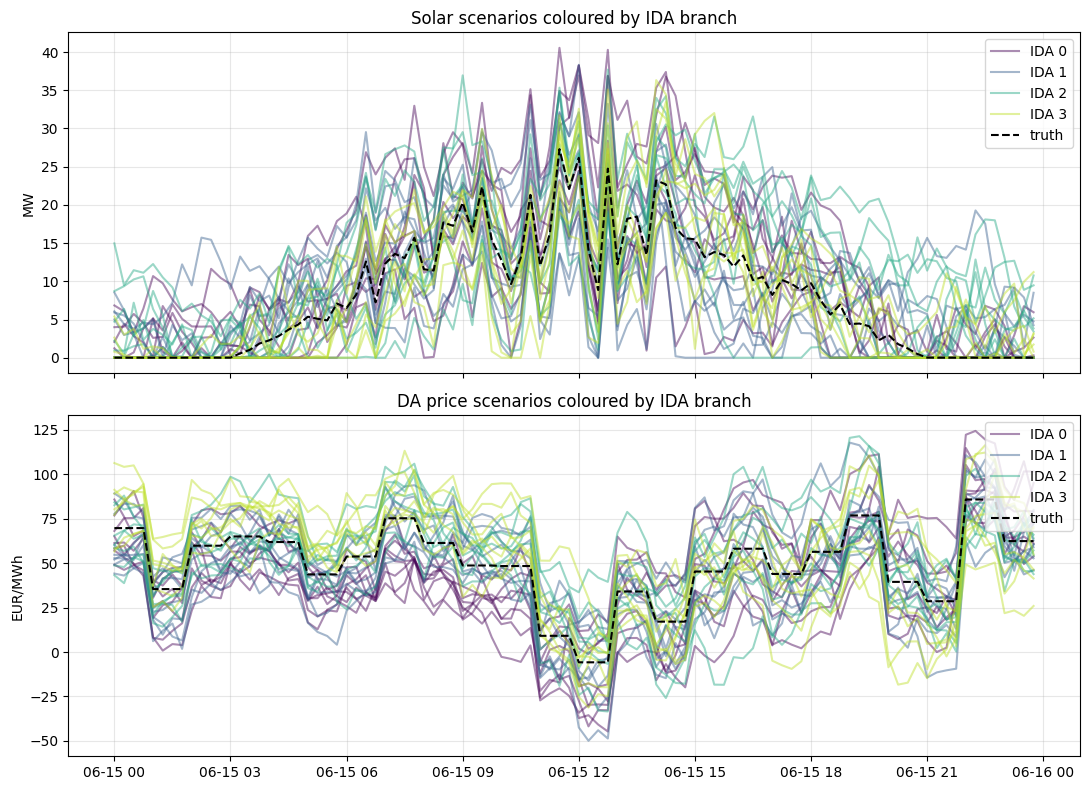

In [23]:
# Visualise the leaf scenarios coloured by their IDA branch.
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
colours = plt.cm.viridis(np.linspace(0, 0.9, len(tree.ida_node_ids)))
ts_local = tree.timestamps.tz_convert('Europe/Tallinn')
for k in tree.ida_node_ids:
    members = np.where(tree.leaf_to_ida == k)[0]
    for j, leaf in enumerate(members):
        axes[0].plot(ts_local, tree.solar_mw[leaf],   color=colours[k],
                     alpha=0.45, label=f'IDA {k}' if j == 0 else None)
        axes[1].plot(ts_local, tree.da_price[leaf], color=colours[k],
                     alpha=0.45, label=f'IDA {k}' if j == 0 else None)
axes[0].plot(ts_local, truth.solar_mw,    color='black', linestyle='--', label='truth')
axes[1].plot(ts_local, truth.da_price_mtu, color='black', linestyle='--', label='truth')
axes[0].set_ylabel('MW');         axes[0].set_title('Solar scenarios coloured by IDA branch')
axes[1].set_ylabel('EUR/MWh');    axes[1].set_title('DA price scenarios coloured by IDA branch')
axes[0].legend(loc='upper right'); axes[1].legend(loc='upper right')
fig.tight_layout()
plt.show()

Tree solve: TerminationCondition.optimal, expected profit 9592.53 EUR


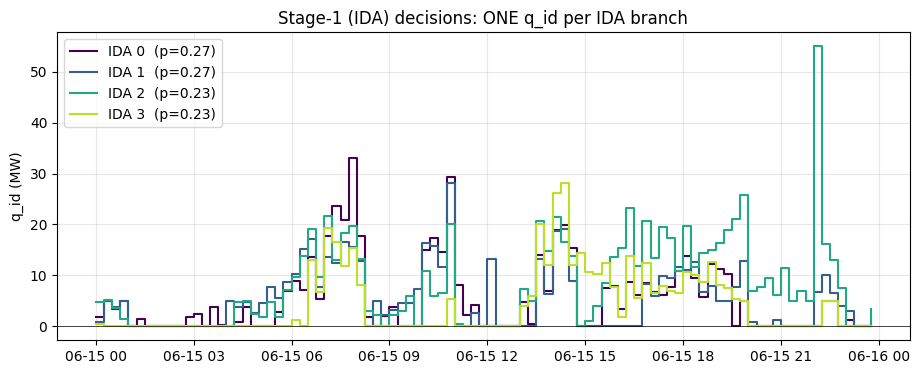

In [24]:
# Solve the tree model and verify non-anticipativity:
# all leaves in the same IDA branch must share q_id at every t.
import pyomo.environ as pyo
from solarbess.optim.tree_builder import build_tree_stochastic_model

m_tree = build_tree_stochastic_model(
    times=sc_da.timestamps, tree=tree,
    battery=cfg.battery, market=cfg.market,
    dt_hours=cfg.dt_hours, soc_initial_mwh=cfg.battery.soc_initial_mwh,
)
res = solve_highs(m_tree, time_limit_s=60.0)
print(f'Tree solve: {res.termination}, expected profit {res.objective:.2f} EUR')

# Plot q_id per IDA branch (4 lines instead of 30 in two-stage)
fig, ax = plt.subplots(figsize=(11, 4))
for k in tree.ida_node_ids:
    q_id_k = np.array([pyo.value(m_tree.q_id_ida[k, t]) for t in m_tree.T])
    ax.step(ts_local, q_id_k, where='post', color=colours[k],
            label=f'IDA {k}  (p={tree.ida_probabilities[k]:.2f})')
ax.set_ylabel('q_id (MW)'); ax.set_title('Stage-1 (IDA) decisions: ONE q_id per IDA branch')
ax.legend(); ax.axhline(0, color='black', linewidth=0.5)
plt.show()

In [25]:
# Run the TreePolicy alongside the two-stage stochastic and oracle
tree_cmp = {
    'pyomo_sto_lp':   PyomoPolicy(cfg.battery, cfg.market, cfg.dt_hours, use_stochastic=True),
    'tree_ida3':      TreePolicy(cfg.battery, cfg.market, cfg.dt_hours, n_ida_nodes=3),
    'tree_ida5':      TreePolicy(cfg.battery, cfg.market, cfg.dt_hours, n_ida_nodes=5),
    'oracle':         OraclePolicy(cfg.battery, cfg.market, cfg.dt_hours, truth),
}
tree_results = {n: run_episode(truth, cfg, p, fg, forecast_seed=99) for n, p in tree_cmp.items()}
print(f'{"policy":<16}  {"PnL":>10}')
for n, r in tree_results.items():
    print(f'{n:<16}  {r.pnl.total:>10.2f}')
print()
print('Interpretation:')
print('- two-stage allows q_id per leaf (implicit peek) -> often higher in-sample profit')
print('- tree forces q_id per IDA branch -> realistic non-anticipativity, smaller in-sample profit')
print('- oracle = perfect-foresight LP, upper bound')

policy                   PnL
pyomo_sto_lp         8340.47
tree_ida3            8327.98
tree_ida5            8306.30
oracle               8825.84

Interpretation:
- two-stage allows q_id per leaf (implicit peek) -> often higher in-sample profit
- tree forces q_id per IDA branch -> realistic non-anticipativity, smaller in-sample profit
- oracle = perfect-foresight LP, upper bound


## 14. Recap

What we exercised in this notebook:

| Section | Phase | Module touched | Verification |
|---|---|---|---|
| 1 | 1 | `world/truth.py`, `world/layers.py` | TruthPath with 4 price layers + solar |
| 2 | 1 | `world/truth.py` (latent) | regime/clearness/seasonality diagnostics |
| 3 | 1 | `world/layers.py` (L2+L3 coupling) | corr(midday solar, midday DA) < −0.2 |
| 4 | 1 | `asset/battery.py` | 12-step SoC trajectory + solar-only charge cap |
| 5 | 1 | `world/oracle.py` | information firewall masks future truth |
| 6 | 2 | `forecast/scenarios.py`, `forecast/error_model.py` | fan plot + lead-time variance shrink |
| 7 | 1 | `optim/builder.py`, `optim/solve.py` | deterministic LP on truth = oracle bound |
| 8 | 1-2 | `policy/*`, `simulator/episode.py` | 4 policies, same day, same forecast seed |
| 9 | 2 | `eval/harness.py`, `eval/stats.py` | 15-episode paired runs, Wilcoxon p-values |
| 10 | 3 | `optim/cvar.py` | λ sweep: trades expected profit for tail |
| **11** | **4** | `optim/helpers.add_no_simultaneous_charge_discharge` | MILP eliminates simultaneous charge/discharge |
| **12** | **5** | `policy/pyomo_policy._rolling_mpc_dispatch` | dispatch re-solves with fresh forecasts |
| **13** | **6** | `forecast/tree.py`, `optim/tree_builder.py`, `policy/tree_policy.py` | scenario tree + non-anticipativity |

All six phases of the original plan are now implemented. Further extensions:
- **Real-data ingestion**: vintage-safe Nord Pool / Elering / ENTSO-E / ECMWF (Estonian forecasting PDF).
- **More elaborate scenario trees**: deeper trees, multiple stage-1 features, scenario reduction.
- **Continuous intraday market** with per-period gate times instead of three fixed rounds.
